In [1]:
%reload_ext autoreload
%autoreload 2

import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HDF5_USE_FILE_LOCKING"]= "FALSE"
    
from scipy.constants import mu_0
import MaNTA

from Objective import make_objective


import jax
import jax.numpy as jnp
import equinox as eqx
import yancc

from yancc_wrapper import yancc_data

import desc
from desc import set_device
set_device("gpu")
import desc.io
from desc.equilibrium import Equilibrium
from desc.geometry import FourierRZToroidalSurface
from desc.grid import Grid, LinearGrid
from desc.objectives import (
    AspectRatio,
    FixBoundaryR,
    FixBoundaryZ,
    FixCurrent,
    FixPsi,
    ForceBalance,
    LinearObjectiveFromUser,
    ObjectiveFunction,
    ObjectiveFromUser,
    RotationalTransform,
    Volume,
)
from desc.profiles import SplineProfile



Using gpu implementation
Using cache directory: /global/cfs/cdirs/mp217/eatocco/__pycache__
[CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]


In [2]:
from Stellarator import StellaratorTransport

fname = "stellarator_opt2"

eq_name = "eq2"

st_config = {
    "SourceCenter": 0.2,
    "SourceHeight": 200.0,
    "SourceWidth": 0.4,
    "EdgeTemperature":0.1,
    "EdgeDensity": 0.0,
    "n0": 0.5,
}
# runner = MaNTA.Runner(st)

# # %%
solver_config = {
    "OutputFilename": fname,
    "Polynomial_degree": 4,
    "Grid_size": 4,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": 0.9,
    "Relative_tolerance": 0.01,
    "Absolute_tolerance": [1e-4],
    "delta_t": 0.0001,
    "MinStepSize": 1e-8,
    "restart": False,
    "solveAdjoint": True, 
}

config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

points =  MaNTA.getNodes(solver_config["Lower_boundary"], solver_config["Upper_boundary"], solver_config["Grid_size"], solver_config["Polynomial_degree"])
print(points)
yancc_rho = jnp.array(points)
yancc_ntheta = 17
yancc_nzeta = 45

# to allow maximum flexibility to match manta, we use a spline with the same control points as manta \
# + axis and lcfs
# initial pressure is all zeros, can change this if desired
pressure_rho = jnp.concatenate([jnp.zeros(1), yancc_rho, jnp.ones(1)])
desc_pressure = SplineProfile(jnp.zeros_like(pressure_rho), pressure_rho)

eq_est = desc.examples.get("ESTELL")
surf = eq_est.get_surface_at(rho=1)
eq = Equilibrium(M=8, N=8, Psi=0.1, surface=surf, pressure=desc_pressure)
eq = eq.solve(x_scale="ess")[0]

# eq = desc.io.load("eq_self_consistent_pressure.h5")
# desc_pressure = eq.get_profile('p')
eq_init = eq.copy()

V0 = eq.compute("V")["V"]
# yancc_wrapper = yancc_data.from_eq(points, grid = yancc_grid,rho = yancc_rho, Density=Density, eq=eq_init, nt = yancc_ntheta, nz = yancc_nzeta)
yancc_wrapper = yancc_data.from_eq(points, eq=eq_init, nt = yancc_ntheta, nz = yancc_nzeta)

st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
st.run()


[0.00550614 0.04637416 0.1125     0.17862584 0.21949386 0.23050614
 0.27137416 0.3375     0.40362584 0.44449386 0.45550614 0.49637416
 0.5625     0.62862584 0.66949386 0.68050614 0.72137416 0.7875
 0.85362584 0.89449386]
Building objective: force
Precomputing transforms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed current
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Number of parameters: 856
Number of objectives: 5346

Starting optimization
Using method: lsq-exact
Optimization terminated successfully.
`ftol` condition satisfied. (ftol=1.00e-02)
         Current function value: 7.535e-08
         Total delta_x: 3.111e-01
         Iterations: 33
         Function evaluations: 41
         Jacobian ev

INFO: Using default value for configuration option Grid_points
INFO: Using default value for configuration option High_Grid_Boundary
INFO: Using default value for configuration option Lower_Boundary_Fraction
INFO: Using default value for configuration option Upper_Boundary_Fraction
INFO: Creating grid with 4 cells from x = 0 to x = 0.9
Total HDG degrees of freedom 65
INFO: Using default value for configuration option tZero
INFO: Using default value for configuration option OutputPoints
INFO: Using default value for configuration option SteadyStateTolerance
INFO: Using default value for configuration option useCalcIC
INFO: Using default value for configuration option WriteOutput
Configuration done.
Setting initial conditions
Residual norm at t = 0: inf
Residual norm at t = 0: 11.1888
Residual norm at t = 0: 0
Residual norm at t = 0: 0.00538945


Number of Residual Evaluations due to IDACalcIC 3


Residual norm at t = 0: 0.698489
Residual norm at t = 1e-07: 0
Residual norm at t = 1e-07: 3.60588
Residual norm at t = 5.25578e-08: 0.00172122
Residual norm at t = 5.25578e-08: 1.71556
Residual norm at t = 9.4794e-08: 0.000573771
Residual norm at t = 9.4794e-08: 0.0188245
Residual norm at t = 1.79266e-07: 0.00139663
Residual norm at t = 1.79266e-07: 0.0442416
Residual norm at t = 3.48211e-07: 0.0068949
Residual norm at t = 3.48211e-07: 0.139316
Residual norm at t = 6.86101e-07: 0.000472349
Residual norm at t = 6.86101e-07: 0.256802
Residual norm at t = 1.02399e-06: 0.00137202
Residual norm at t = 1.69977e-06: 0.203583
Residual norm at t = 1.69977e-06: 0.674042
Residual norm at t = 2.30797e-06: 0.0030658
Residual norm at t = 2.30797e-06: 0.64222
Residual norm at t = 2.91617e-06: 0.0515335
Residual norm at t = 3.52438e-06: 2.60809
Residual norm at t = 4.74078e-06: 0.697623
Residual norm at t = 4.74078e-06: 0.49997
Residual norm at t = 4.37716e-06: 0.0526799
Residual norm at t = 4.37716e

Writing output at 0.0001 ( 32 timesteps )


...

Residual norm at t = 0.0004: 44.6865


 dy/dt norm inferred from lambdas is 0.898903
Steady State achieved at time t = 0.0004
Total Number of Timesteps             :38
Total Number of Residual Evaluations  :67
Total Number of Jacobian Computations :13
Computing adjoints


INFO: Computing adjoints for 7784 parameters
Successfully computed dgdp
7784
20


Done.


(Array([1180.3162], dtype=float32),
 Array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32))

In [3]:
solver_config = {
    "OutputFilename": fname,
    "Polynomial_degree": 4,
    "Grid_size": 4,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": 0.9,
    "Relative_tolerance": 0.01,
    "Absolute_tolerance": [1e-4],
    "delta_t": 1e-7,
    "MinStepSize": 1e-11,
    "useCalcIC": False,
    "restart": True,
    "solveAdjoint": True, 
}

config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

manta_objective = make_objective(config, vectorized=True)

# def manta_yancc_fun(fields, grid, Vprime):

#     stored_energy, pressure = Objective(fields, grid, Vprime) 

#     return stored_energy, pressure

def objective_from_user_fun(grid, data):
  # note: don't change the signature to this function
    yancc_dat = {
        "B_sup_t": data["B^theta"],
        "B_sup_z": data["B^zeta"],
        "B_sub_t": data["B_theta"],
        "B_sub_z": data["B_zeta"],
        "Bmag": data["|B|"],
        "dBdt": data["|B|_t"],
        "dBdz": data["|B|_z"],
        "sqrtg": data["sqrt(g)"],
    }

    yancc_dat = {
        key: grid.meshgrid_reshape(val, "rtz") for key, val in yancc_dat.items()
    }

    yancc_dat["Psi"] = grid.compress(
        data["Psi"] / grid.nodes[:, 0] ** 2, surface_label="rho"
    )
    yancc_dat["a_minor"] = jnp.full(grid.num_rho, data["a"])
    yancc_dat["R_major"] = jnp.full(grid.num_rho, data["R0"])
    yancc_dat["iota"] = grid.compress(data["iota"], surface_label="rho")
    yancc_dat["rho"] = grid.compress(grid.nodes[:, 0], surface_label="rho")

    V = grid.compress(data['V(r)'])
    V_r = grid.compress(data['V_r(r)'])
    Vprime = V_r/V[-1]

    fields = jax.vmap(lambda d: yancc.field.Field(**d, NFP=grid.NFP))(yancc_dat)

    desc_pressure = grid.compress(data["p"], surface_label="rho")
    
    stored_energy, manta_pressure = manta_objective(fields, grid, Vprime)
    
    
    pressure_error = manta_pressure - desc_pressure

    # optimization is easiest for least squares objectives, so instead of maximizing
    # stored energy we minimize 1/stored_energy^2 (the squaring happens later)
    return jnp.append(pressure_error, 1 / stored_energy)

    

In [4]:
import interpax

yancc_rho = yancc_wrapper.rho
pressure_rho = jnp.concatenate([jnp.zeros(1), yancc_rho, jnp.ones(1)])
desc_pressure = SplineProfile(jnp.zeros_like(pressure_rho), pressure_rho)

# grid where desc needs to evaluate field for yancc/manta
yancc_desc_grid = LinearGrid(
    rho=yancc_rho, theta=yancc_ntheta, zeta=yancc_nzeta, NFP=eq.NFP
)


desc_data = eq.compute(["V(r)", "V_r(r)"], grid=yancc_desc_grid)

V = yancc_desc_grid.compress(desc_data['V(r)'])
Vn = V/V[-1] # normalize
Vn = interpax.CubicSpline(yancc_rho, Vn)

rho_from_normalized_volume = lambda Vnorm : desc.backend.root_scalar(lambda x: Vn(x) - Vnorm, jnp.sqrt(Vnorm))    

In [5]:
domain_boundary_rho = rho_from_normalized_volume(0.9)
print(domain_boundary_rho)
def pressure_constraint_fun(params):
    # function to fix dp/dr=0 at axis and p=0 at edge
    # can modify this for other BC (eg fix p at rho=0.8)
    p_l = params["p_l"]
    dp0 = desc_pressure(Grid(jnp.zeros((1, 3)), jitable=True), p_l, dr=1)
    p1 = desc_pressure(Grid(jnp.zeros((1, 3)).at[0, 0].set(domain_boundary_rho), jitable=True), p_l)
    return jnp.array([dp0, p1]).squeeze()

pressure_constraint_target = jnp.array([0.0, st.getPressure([0.9])[0]])

# initial optimization just to get self consistent pressure with fixed initial boundary
pressure_error_weight = jnp.full(yancc_desc_grid.num_rho, 0.01)
stored_energy_weight = 0
objective_from_user_weight = jnp.append(pressure_error_weight, stored_energy_weight)

objectives = [
    ObjectiveFromUser(
        objective_from_user_fun,
        eq,
        target=0,
        weight=objective_from_user_weight,
        grid=yancc_desc_grid,
        deriv_mode="fwd", 
        use_jit=False,# need this assuming manta only has vjp, if using jvp switch to fwd
    )
]

constraints = [
    ForceBalance(eq=eq),  # J x B - grad(p) = 0
    FixCurrent(eq=eq),  # fix zero current, eventually should use real bootstrap
    FixPsi(eq=eq),  # fix total magnetic flux
    FixBoundaryR(eq=eq),  # fix boundary shape
    FixBoundaryZ(eq=eq),
    LinearObjectiveFromUser(
        pressure_constraint_fun, eq, target=pressure_constraint_target
    ),
]

objective = ObjectiveFunction(objectives)

eq, info_out = eq.optimize(
    objective=objective,
    constraints=constraints,
    optimizer="proximal-lsq-exact",
    maxiter=50,
    verbose=3,
    ftol=0.05,
    x_scale="ess",
    copy=True,
    options={
        # pressure is O(1e4) so we use a larger trust region for the self consistency part
        "initial_trust_radius": 1000.0,
        "max_trust_radius": 1e5,
    },
)
# save for later
eq_self_consistent_pressure = eq.copy()
eq_self_consistent_pressure.save(eq_name + "_self_consistent_pressure.h5")

0.8954422895127481
Building objective: Custom
yancc_wrapper initialized successfully.
configuring
Successfully created StellaratorTransport object
error when trying to set method compute_scaled
error when trying to set method compute_scaled_error
error when trying to set method compute_unscaled
error when trying to set method compute_scalar
error when trying to set method jac_scaled
error when trying to set method jac_scaled_error
error when trying to set method jac_unscaled
error when trying to set method jvp_scaled
error when trying to set method jvp_scaled_error
error when trying to set method jvp_unscaled
error when trying to set method hess
error when trying to set method grad
Timer: Objective build = 7.62 sec
Building objective: force
Precomputing transforms


INFO: Using default value for configuration option RestartFile
Total HDG degrees of freedom 65
INFO: Using default value for configuration option tZero
INFO: Using default value for configuration option OutputPoints
INFO: Using default value for configuration option SteadyStateTolerance
INFO: Using default value for configuration option WriteOutput
Configuration done.


Timer: Precomputing transforms = 106 ms
Timer: Objective build = 124 ms
Timer: Objective build = 1.65 ms
Timer: Eq Update LinearConstraintProjection build = 2.31 sec
Timer: Proximal projection build = 31.7 sec
Building objective: fixed current
Building objective: fixed Psi
Building objective: lcfs R
Building objective: lcfs Z
Building objective: custom linear
Timer: Objective build = 3.02 sec
Timer: LinearConstraintProjection build = 7.22 sec
Number of parameters: 20
Number of objectives: 21
Timer: Initializing the optimization = 43.1 sec

Starting optimization
Using method: proximal-lsq-exact
yancc_wrapper initialized successfully.
configuring
Successfully created StellaratorTransport object


INFO: Using default value for configuration option RestartFile
Total HDG degrees of freedom 65
INFO: Using default value for configuration option tZero
INFO: Using default value for configuration option OutputPoints
INFO: Using default value for configuration option SteadyStateTolerance
INFO: Using default value for configuration option WriteOutput
Configuration done.
Setting initial conditions
Residual norm at t = 0: inf
Residual norm at t = 0: 10.0618


Number of Residual Evaluations due to IDACalcIC 0


...

Number of Residual Evaluations due to IDACalcIC 0


Residual norm at t = 0: 113.851
Residual norm at t = 1e-07: inf
Residual norm at t = 1e-07: 1.19353
Residual norm at t = 1e-07: 113.857


Writing output at 1e-07 ( 1 timesteps )
 dy/dt norm inferred from lambdas is 0.0481687
Steady State achieved at time t = 1e-07
Total Number of Timesteps             :1
Total Number of Residual Evaluations  :2
Total Number of Jacobian Computations :1
Computing adjoints


INFO: Computing adjoints for 7784 parameters
Successfully computed dgdp
7784
20


Done.
                                                                 Start  -->   End
yancc_wrapper initialized successfully.
configuring
Successfully created StellaratorTransport object
yancc_wrapper initialized successfully.
configuring
Successfully created StellaratorTransport object
Total (sum of squares):                                      9.080e+02  -->   5.652e+01, 
yancc_wrapper initialized successfully.
configuring
Successfully created StellaratorTransport object
yancc_wrapper initialized successfully.
configuring
Successfully created StellaratorTransport object
Maximum absolute Custom objective value:                     1.336e+03  -->   7.779e+02 (Unknown)
Minimum absolute Custom objective value:                     8.393e-04  -->   8.392e-04 (Unknown)
Average absolute Custom objective value:                     8.390e+02  -->   1.052e+02 (Unknown)
Maximum absolute Custom objective value:                     1.336e+03  -->   7.779e+02 (normalized)
Minimum absolute Custom

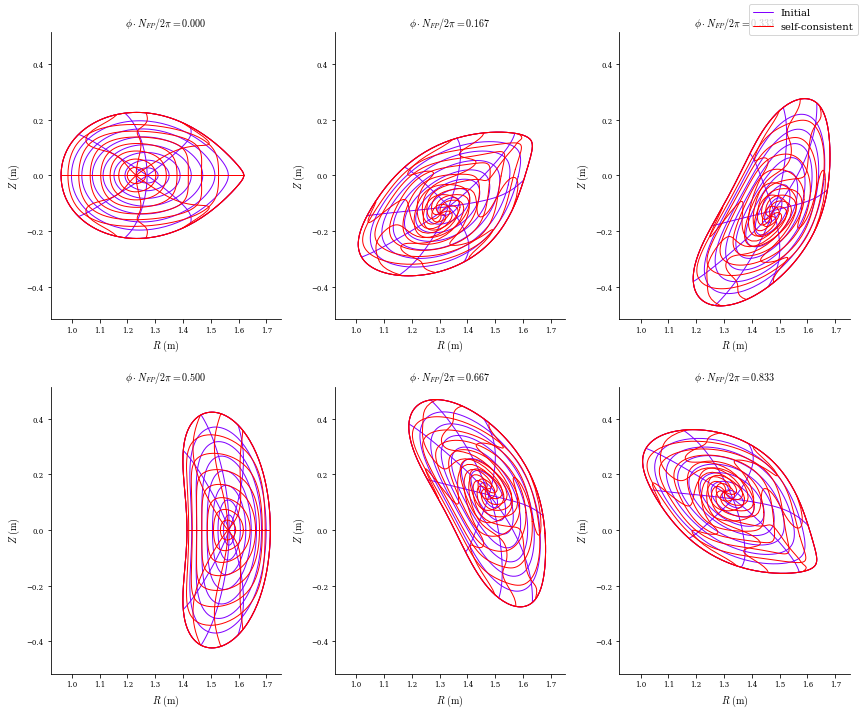

In [6]:
from desc.plotting import plot_comparison

plot_comparison(
    eqs=[eq_init, eq], labels=["Initial", "self-consistent"]
);

In [7]:
solver_config = {
    "OutputFilename": fname,
    "Polynomial_degree": 4,
    "Grid_size": 4,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": 0.9,
    "Relative_tolerance": 0.01,
    "Absolute_tolerance": [1e-4],
    "delta_t": 1e-6,
    "MinStepSize": 1e-11,
    "useCalcIC": False,
    "restart": True,
    "solveAdjoint": True, 
}

config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

manta_objective = make_objective(config, vectorized=True)

# def manta_yancc_fun(fields, grid, Vprime):

#     stored_energy, pressure = Objective(fields, grid, Vprime) 

#     return stored_energy, pressure

def objective_from_user_fun(grid, data):
  # note: don't change the signature to this function
    yancc_dat = {
        "B_sup_t": data["B^theta"],
        "B_sup_z": data["B^zeta"],
        "B_sub_t": data["B_theta"],
        "B_sub_z": data["B_zeta"],
        "Bmag": data["|B|"],
        "dBdt": data["|B|_t"],
        "dBdz": data["|B|_z"],
        "sqrtg": data["sqrt(g)"],
    }

    yancc_dat = {
        key: grid.meshgrid_reshape(val, "rtz") for key, val in yancc_dat.items()
    }

    yancc_dat["Psi"] = grid.compress(
        data["Psi"] / grid.nodes[:, 0] ** 2, surface_label="rho"
    )
    yancc_dat["a_minor"] = jnp.full(grid.num_rho, data["a"])
    yancc_dat["R_major"] = jnp.full(grid.num_rho, data["R0"])
    yancc_dat["iota"] = grid.compress(data["iota"], surface_label="rho")
    yancc_dat["rho"] = grid.compress(grid.nodes[:, 0], surface_label="rho")

    V = grid.compress(data['V(r)'])
    V_r = grid.compress(data['V_r(r)'])
    Vprime = V_r/V[-1]

    fields = jax.vmap(lambda d: yancc.field.Field(**d, NFP=grid.NFP))(yancc_dat)

    desc_pressure = grid.compress(data["p"], surface_label="rho")
    
    stored_energy, manta_pressure = manta_objective(fields, grid, Vprime)
    
    
    pressure_error = manta_pressure - desc_pressure

    # optimization is easiest for least squares objectives, so instead of maximizing
    # stored energy we minimize 1/stored_energy^2 (the squaring happens later)
    return jnp.append(pressure_error, 1 / stored_energy)


desc_data = eq.compute(["V(r)", "V_r(r)"], grid=yancc_desc_grid)

V = yancc_desc_grid.compress(desc_data['V(r)'])
Vn = V/V[-1] # normalize
Vn = interpax.CubicSpline(yancc_rho, Vn)

rho_from_normalized_volume = lambda Vnorm : desc.backend.root_scalar(lambda x: Vn(x) - Vnorm, jnp.sqrt(Vnorm))   



domain_boundary_rho = rho_from_normalized_volume(0.9)
print(domain_boundary_rho)
def pressure_constraint_fun(params):
    # function to fix dp/dr=0 at axis and p=0 at edge
    # can modify this for other BC (eg fix p at rho=0.8)
    p_l = params["p_l"]
    dp0 = desc_pressure(Grid(jnp.zeros((1, 3)), jitable=True), p_l, dr=1)
    p1 = desc_pressure(Grid(jnp.zeros((1, 3)).at[0, 0].set(domain_boundary_rho), jitable=True), p_l)
    return jnp.array([dp0, p1]).squeeze()



pressure_constraint_target = jnp.array([0.0, st.getPressure([0.9])[0]])

0.8971161955142106


In [ ]:
# NOTES:
# Use short time step for self consistent pressure
# Possibly use a smaller weight - definitely too large
# Redo config with a larger timestep for main optimization
# Probably lower teh tolerance
# SUNDIALS notes
# Should adjust the initial timestepping 
# Possibly do one time step and adjust initial timestep based on that
# or just use calc ic and use the post calc ic residual norm

# main optimization, varying boundary to maximize stored energy
eq = eq_init.copy()

# other objectives are non-dimensionalized, so weights should account for that
# and handle relative weighting, this will likely need trial and error
pressure_error_weight = jnp.full(yancc_desc_grid.num_rho, 0.01)
stored_energy_weight = 1.0
objective_from_user_weight = jnp.append(pressure_error_weight, stored_energy_weight)

objectives = [
    AspectRatio(eq=eq, target=6, weight=10),
    Volume(eq=eq, target=V0, weight=10),
    RotationalTransform(eq=eq, target=0.42, weight=10),
    ObjectiveFromUser(
        objective_from_user_fun,
        eq,
        target=0,
        weight=objective_from_user_weight,
        grid=yancc_desc_grid,
        deriv_mode="fwd", 
        use_jit=False,# need this assuming manta only has vjp, if using jvp switch to fwd
    ),
]
constraints = [
    ForceBalance(eq=eq),  # J x B - grad(p) = 0
    FixCurrent(eq=eq),  # fix zero current, eventually should use real bootstrap
    FixPsi(eq=eq),  # fix total magnetic flux
    LinearObjectiveFromUser(
        pressure_constraint_fun, eq, target=pressure_constraint_target
    ),
]

objective = ObjectiveFunction(objectives)

eq, info_out = eq.optimize(
    objective=objective,
    constraints=constraints,
    optimizer="proximal-lsq-exact",
    maxiter=50,
    verbose=3,
    x_scale="ess",
    options={
        "max_trust_radius": 0.1,
    },
    copy=True,
)

eq_optimized = eq.copy()


# do a final pass with just the self consistency part to make sure profiles match
pressure_error_weight = jnp.full(yancc_desc_grid.num_rho, 1.0)
stored_energy_weight = 0
objective_from_user_weight = jnp.append(pressure_error_weight, stored_energy_weight)

objectives = [
    ObjectiveFromUser(
        objective_from_user_fun,
        eq,
        target=0,
        weight=objective_from_user_weight,
        grid=yancc_desc_grid,
        deriv_mode="fwd", 
        use_jit=False,# need this assuming manta only has vjp, if using jvp switch to fwd
    )
]

constraints = [
    ForceBalance(eq=eq),  # J x B - grad(p) = 0
    FixCurrent(eq=eq),  # fix zero current, eventually should use real bootstrap
    FixPsi(eq=eq),  # fix total magnetic flux
    FixBoundaryR(eq=eq),  # fix boundary shape
    FixBoundaryZ(eq=eq),
    LinearObjectiveFromUser(
        pressure_constraint_fun, eq, target=pressure_constraint_target
    ),
]

objective = ObjectiveFunction(objectives)

eq, info_out = eq.optimize(
    objective=objective,
    constraints=constraints,
    optimizer="proximal-lsq-exact",
    maxiter=50,
    verbose=3,
    x_scale="ess",
    copy=True,
    options={
        "initial_trust_radius": 1e3,
        "max_trust_radius": 1e5,
    },
)
eq_optimized_self_consistent = eq.copy()

Building objective: aspect ratio
Precomputing transforms
Timer: Precomputing transforms = 46.9 ms
Building objective: volume
Precomputing transforms
Timer: Precomputing transforms = 46.9 ms
Building objective: rotational transform
Precomputing transforms
Timer: Precomputing transforms = 1.60 sec
Building objective: Custom
yancc_wrapper initialized successfully.
configuring
Successfully created StellaratorTransport object
error when trying to set method compute_scaled
error when trying to set method compute_scaled_error
error when trying to set method compute_unscaled
error when trying to set method compute_scalar
error when trying to set method jac_scaled
error when trying to set method jac_scaled_error
error when trying to set method jac_unscaled
error when trying to set method jvp_scaled
error when trying to set method jvp_scaled_error
error when trying to set method jvp_unscaled
error when trying to set method hess
error when trying to set method grad
Timer: Objective build = 2.12 s

INFO: Using default value for configuration option RestartFile
Total HDG degrees of freedom 65
INFO: Using default value for configuration option tZero
INFO: Using default value for configuration option OutputPoints
INFO: Using default value for configuration option SteadyStateTolerance
INFO: Using default value for configuration option WriteOutput
Configuration done.


Timer: Precomputing transforms = 101 ms
Timer: Objective build = 117 ms
Timer: Objective build = 1.64 ms
Timer: Eq Update LinearConstraintProjection build = 2.67 sec
Timer: Proximal projection build = 17.9 sec
Building objective: fixed current
Building objective: fixed Psi
Building objective: custom linear
Timer: Objective build = 966 ms


In [ ]:
eq_optimized_self_consistent.save(eq_name + "optimized_equilibrium.h5")

In [ ]:
from desc.plotting import plot_comparison

plot_comparison(
    eqs=[eq_init, eq], labels=["Initial", "self-consistent"]
);

In [ ]:
from desc.plotting import plot_boundaries

plot_comparison(
    eqs=[eq_init, eq_optimized, eq], labels=["Initial", "optimized", "self-consistent"]
);

In [ ]:
plot_boundaries(
    eqs=[eq_init, eq_optimized, eq], labels=["Initial", "optimized", "self-consistent"]
);